# Arrow Sudoku

In [2]:
import pulp as plp

## What is Arrow Sudoku?


In addition to the standard Sudoku rules, in Arrow Sudoku the digits in the circled cells must be the sum of the digits along the arrow point out of it. 

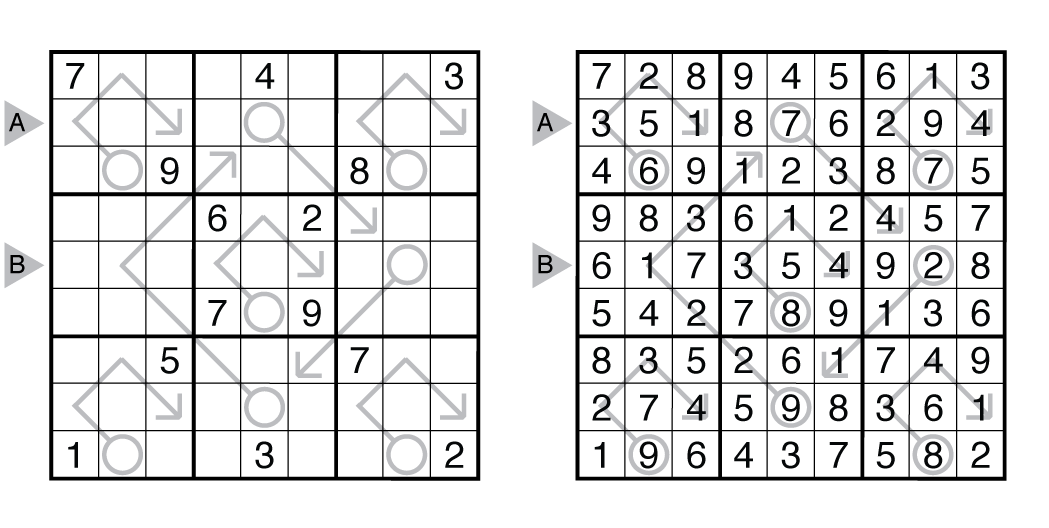

## Problem Statement

### Decision Variables:
- $i$: row index
- $j$: column index
- $v$: value of the cel
- $G_{ijv}$: Grid variable at row $i$, column $j$ with value $v$.
  
$G_{ijv} \in \{0, 1\}$ for row,col:  $i,j \in \{0 ... 8\}$, value: $ v\in \{1...9\}$.

Binary variable = 1 if cell (row,col) contains digit 'value', 0 otherwise.

### Normal Sudoku Constraints:
#### 1. Cell uniqueness: Each cell should contain only 1 value.

For each $(i,j)$:
$$\sum_{v=1}^{9} G_{ijv} = 1$$


#### 2. Row uniqueness: For each row, numbers 1 to 9 can appear only once.

For each row and each value v:
       $$\sum_{col=0}^{8} G_{ijv} \cdot v = v$$


#### 3. Column uniqueness: For each column, numbers from 1 to 9 can appear only once.

For each col and each value v:
       $$\sum_{row=0}^{8} G_{ijv} \cdot v = v$$

#### 4. Box uniqueness:  For each 3×3 box, numbers from 1 to 9 can appear only once.

For each box and value:
$$\sum_{(i,j) \text{ in box}} G_{ijv} \cdot v = v$$


#### 5. Prefilled cells: The prefilled cells should have the same value with the prefilled value.

For each given cell (row, col) with known digit d:
$$\sum_{v=1}^{9} G_{ij v}\cdot v = d$$
where $d$ is the prefilled value of the cell.

### Arrow Sudoku Constraints:


Let $A$ be the set of all arrows in the sudoku and $a \in A$. 

- The base of the arrow (containing the sum of thew arrow) be denoted by the pair $(c_r,c_c)$ where $c_r$ and $c_c$ represent circle row and column respectively.
- The path of the arrow is denoted by the set $P_a = \{(p_{c}^{1},p_{r}^{1}),(p_{c}^{2},p_{r}^{2}),...,(p_{c}^{n},p_{r}^{n})\}$ where $p^n$ denotes each cell on the arrow's path and the pair $(p_{c}^{n},p_{r}^{n})$ denotes the row and column of $p^n$.

For each arrow, the circle should contains the sum of all the numbers on the arrow's path. So the constraint for each arrow:

$$\sum_{v=1}^{9} v \cdot G_{c_r,\, c_c,\, v} \;=\; \sum_{(p_r^k,\, p_c^k) \in P_a} \;\sum_{v=1}^{9} v \cdot G_{p_r^k,\, p_c^k,\, v} \qquad \forall \; a \in A$$

Or in standard LP form:

$$\sum_{v=1}^{9} v \cdot G_{c_r,\, c_c,\, v} \;-\; \sum_{(p_r^k,\, p_c^k) \in P_a} \;\sum_{v=1}^{9} v \cdot G_{p_r^k,\, p_c^k,\, v} \;=\; 0 \qquad \forall \; a \in A$$


## Building the Solver
### Constraint Functions

In [3]:
def add_default_sudoku_constraints(prob, grid_vars, rows, cols, grids, values):
    
    # Constraint to ensure only one value is filled for a cell
    for row in rows:
        for col in cols:
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value] for value in values]),
                                        sense=plp.LpConstraintEQ, rhs=1, name=f"constraint_sum_{row}_{col}"))


    # Constraint to ensure that values from 1 to 9 is filled only once in a row        
    for row in rows:
        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for col in cols]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_row_{row}_{value}"))

    # Constraint to ensure that values from 1 to 9 is filled only once in a column        
    for col in cols:
        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for row in rows]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_col_{col}_{value}"))


    # Constraint to ensure that values from 1 to 9 is filled only once in the 3x3 grid       
    for grid in grids:
        grid_row  = int(grid/3)
        grid_col  = int(grid%3)

        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[grid_row*3+row][grid_col*3+col][value]*value  for col in range(0,3) for row in range(0,3)]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_grid_{grid}_{value}"))

In [4]:
# Prefilled values
def add_prefilled_constraints(prob, input_sudoku, grid_vars, rows, cols, values):
    for row in rows:
        for col in cols:
            if(input_sudoku[row][col] != 0):
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for value in values]), 
                                                    sense=plp.LpConstraintEQ, 
                                                    rhs=input_sudoku[row][col],
                                                    name=f"constraint_prefilled_{row}_{col}"))

In [5]:
# Arrow Constraint
def add_arrow_constraints(prob, grid_vars, arrows, values):

    for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        path = arrow["path"]

        circle_value = plp.lpSum(
            [grid_vars[cr][cc][v] * v for v in values]
        )

        path_sum = plp.lpSum(
            [grid_vars[pr][pc][v] * v for (pr, pc) in path for v in values]
        )

        prob.addConstraint(
            plp.LpConstraint(
                e=circle_value - path_sum,
                sense=plp.LpConstraintEQ,
                rhs=0,
                name=f"constraint_arrow_{idx}",
            )
        )


### Printing Solutions Helper Functions 

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba


ARROW_PALETTE = [
    '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
    '#42d4f4', '#f032e6', '#bfef45', '#469990', '#dcbeff',
    '#9A6324', '#800000', '#aaffc3', '#808000', '#000075',
    '#ff6347', '#a9a9a9', '#e6beff', '#ffe119', '#fabebe',
    '#00a86b', '#1e90ff', '#ffd700', '#7b68ee', '#20b2aa',
    '#db7093', '#556b2f', '#cd853f', '#8b0000', '#2e8b57',
]


def _xy(col, row):
    """Grid (row, col) → plot center (x, y)."""
    return col + 0.5, 8 - row + 0.5


def _draw_on_ax(ax, input_sudoku, arrows, data, subtitle):
    """Draw one Arrow Sudoku board on the given axes."""
    ax.set_xlim(-0.05, 9.05)
    ax.set_ylim(-0.05, 9.05)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(subtitle, fontsize=14, fontweight='bold', pad=12)

    # Build lookup
    circle_set = set()
    path_set = set()
    cell_to_arrow = {}
    for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        circle_set.add((cr, cc))
        cell_to_arrow[(cr, cc)] = idx
        for p in arrow["path"]:
            path_set.add(tuple(p))
            cell_to_arrow.setdefault(tuple(p), idx)

    # Cell backgrounds
    for r in range(9):
        for c in range(9):
            if (r, c) in circle_set:
                fc = '#fff9db'
            elif (r, c) in path_set:
                aidx = cell_to_arrow.get((r, c), 0)
                base = to_rgba(ARROW_PALETTE[aidx % len(ARROW_PALETTE)])
                fc = (*base[:3], 0.08)
            else:
                fc = 'white'
            rect = patches.Rectangle((c, 8 - r), 1, 1,
                                      linewidth=0.3, edgecolor='#cccccc',
                                      facecolor=fc)
            ax.add_patch(rect)

    # Thin grid
    for i in range(10):
        ax.plot([i, i], [0, 9], color='#cccccc', linewidth=0.5)
        ax.plot([0, 9], [i, i], color='#cccccc', linewidth=0.5)

    # 3×3 box borders
    for i in range(0, 10, 3):
        ax.plot([i, i], [0, 9], 'k-', linewidth=2.5)
        ax.plot([0, 9], [i, i], 'k-', linewidth=2.5)

    # Circles
    for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        cx, cy = _xy(cc, cr)
        color = ARROW_PALETTE[idx % len(ARROW_PALETTE)]
        circ = plt.Circle((cx, cy), 0.38, fill=False,
                           edgecolor=color, linewidth=2.0, zorder=5)
        ax.add_patch(circ)

    # Arrow lines + arrowhead on last segment
    for idx, arrow in enumerate(arrows):
        path = arrow["path"]
        if not path:
            continue
        color = ARROW_PALETTE[idx % len(ARROW_PALETTE)]
        circle = arrow["circle"]
        waypoints = [_xy(circle[1], circle[0])]
        for (pr, pc) in path:
            waypoints.append(_xy(pc, pr))

        for i in range(len(waypoints) - 2):
            x0, y0 = waypoints[i]
            x1, y1 = waypoints[i + 1]
            ax.plot([x0, x1], [y0, y1], color=color,
                    linewidth=1.5, solid_capstyle='round', zorder=3)

        if len(waypoints) >= 2:
            x0, y0 = waypoints[-2]
            x1, y1 = waypoints[-1]
            ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(
                            arrowstyle='->,head_width=0.25,head_length=0.16',
                            color=color, lw=1.5, shrinkA=0, shrinkB=3),
                        zorder=3)

    # Digits
    for r in range(9):
        for c in range(9):
            val = data[r][c]
            if val == 0:
                continue
            is_given = (input_sudoku[r][c] != 0)
            dcolor = '#1a1a1a' if is_given else '#2563eb'
            weight = 'bold' if is_given else 'normal'
            ax.text(c + 0.5, 8 - r + 0.5, str(val),
                    fontsize=20, ha='center', va='center',
                    color=dcolor, fontweight=weight, zorder=6)


def draw_arrow_sudoku(input_sudoku, arrows, solution=None,
                      title="Arrow Sudoku"):
    fig, ax = plt.subplots(figsize=(10, 8))
    data = solution if solution is not None else input_sudoku
    _draw_on_ax(ax, input_sudoku, arrows, data, title)

    # Legend
    handles = []
    for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        color = ARROW_PALETTE[idx % len(ARROW_PALETTE)]
        path_str = '→'.join(f"({pr},{pc})" for pr, pc in arrow["path"])
        label = f"A{idx}: ○({cr},{cc}) → {path_str}"
        handles.append(patches.Patch(color=color, label=label))
    if handles:
        ax.legend(handles=handles, loc='upper left',
                  bbox_to_anchor=(1.01, 1.0), fontsize=6,
                  title='Arrows', title_fontsize=7,
                  frameon=True, framealpha=0.9)
    plt.tight_layout()
    plt.show()


def print_arrow_sudoku(input_sudoku, arrows, solution, rows, cols):
    """Side-by-side: unsolved (left) + solved (right)."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    _draw_on_ax(ax1, input_sudoku, arrows, input_sudoku, "Unsolved")
    _draw_on_ax(ax2, input_sudoku, arrows, solution, "Solved")
    plt.tight_layout()
    plt.show()

def extract_solution(grid_vars, rows, cols, values):
    solution = [[0 for col in cols] for row in rows]
    for row in rows:
        for col in cols:
            for value in values:
                if plp.value(grid_vars[row][col][value]):
                    solution[row][col] = value
    return solution

### Solving the Problem

In [7]:
def solve_arrow_sudoku(input_sudoku, arrows):

    prob = plp.LpProblem("Arrow_Sudoku_Solver")

    rows = range(0, 9)
    cols = range(0, 9)
    grids = range(0, 9)
    values = range(1, 10)

    # Decision Variables
    grid_vars = plp.LpVariable.dicts("grid_value", (rows, cols, values), cat="Binary")

    # Objective Function
    objective = plp.lpSum(0)
    prob.setObjective(objective)

    # Normal Sudoku Constraints
    add_default_sudoku_constraints(prob, grid_vars, rows, cols, grids, values)

    # Prefilled Values
    add_prefilled_constraints(prob, input_sudoku, grid_vars, rows, cols, values)

    # Arrow Sudoku Constraints
    add_arrow_constraints(prob, grid_vars, arrows, values)

    prob.solve()

    solution_status = plp.LpStatus[prob.status]
    print(f"Solution Status = {solution_status}")

    if solution_status == "Optimal":
        solution = extract_solution(grid_vars, rows, cols, values)
        print_arrow_sudoku(input_sudoku, arrows, solution, rows, cols)
        return solution
    else:
        print("No feasible solution found.")
        return None

### Example Arrow Sudoku

  ARROW SUDOKU SOLVER
------------------------------------------------------------
GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --cpxlp /tmp/3fec059b24954120943b4a5ea764d25d-pulp.lp -o /tmp/3fec059b24954120943b4a5ea764d25d-pulp.sol
Reading problem data from '/tmp/3fec059b24954120943b4a5ea764d25d-pulp.lp'...
346 rows, 730 columns, 3330 non-zeros
729 integer variables, all of which are binary
2083 lines were read
GLPK Integer Optimizer 5.0
346 rows, 730 columns, 3330 non-zeros
729 integer variables, all of which are binary
Preprocessing...
321 rows, 575 columns, 2608 non-zeros
575 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  9.000e+00  ratio =  9.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 229
Solving LP relaxation...
GLPK Simplex Optimizer 5.0
321 rows, 575 columns, 2608 non-zeros
      0: obj =   0.000000000e+00 inf =   3.877e+02 (87)
    432: obj =   

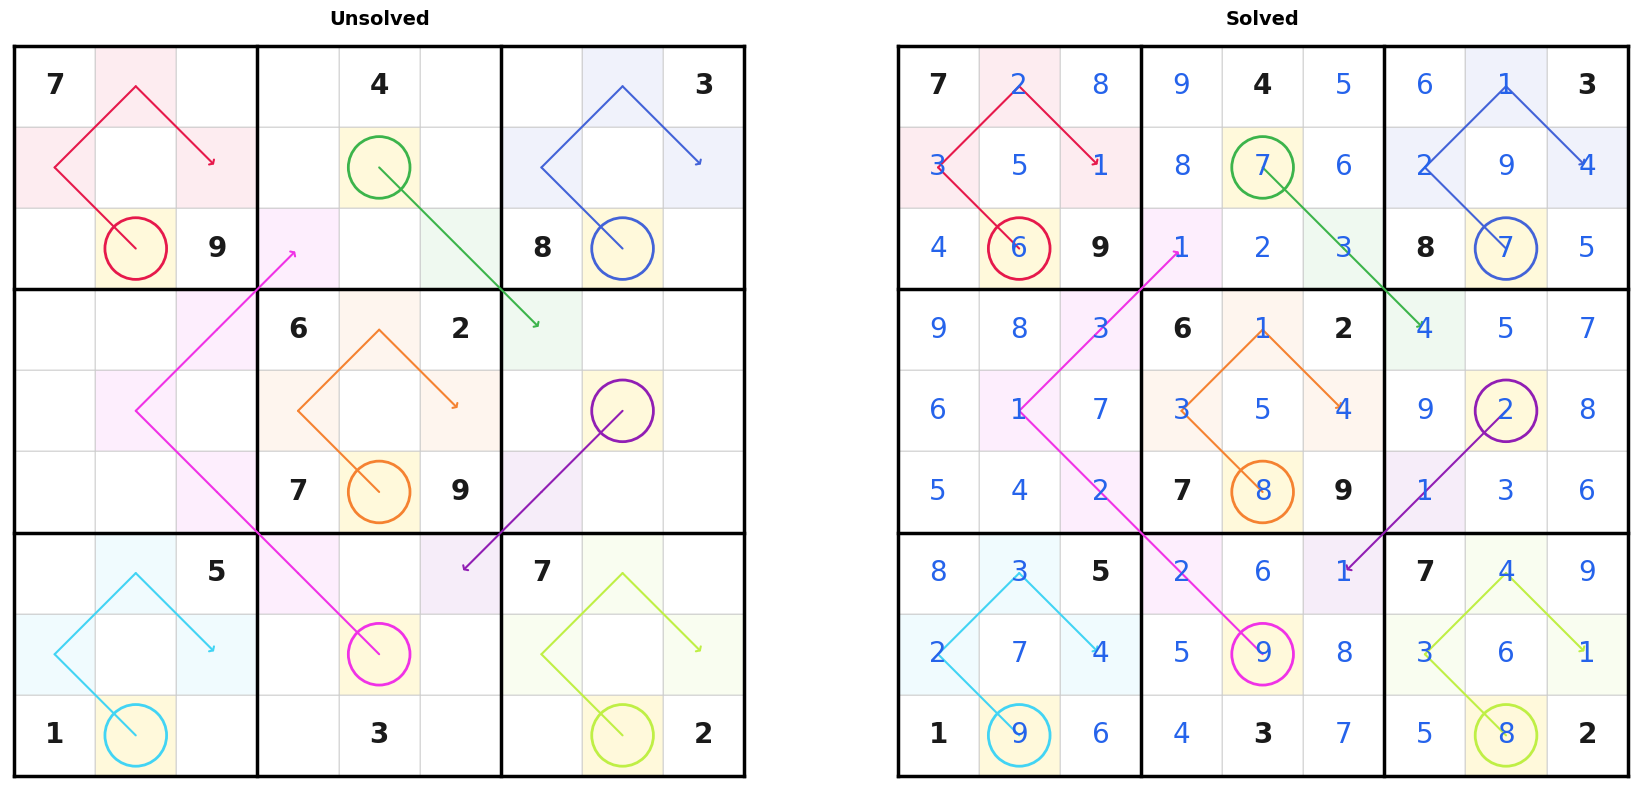

In [8]:
if __name__ == "__main__":

    arrow_sudoku = [
        [7, 0, 0, 0, 4, 0, 0, 0, 3],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 9, 0, 0, 0, 8, 0, 0],
        [0, 0, 0, 6, 0, 2, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 7, 0, 9, 0, 0, 0],
        [0, 0, 5, 0, 0, 0, 7, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 3, 0, 0, 0, 2],
    ]

    arrows = [
        {"circle": (2,1), "path": [(1, 0),(0,1),(1,2)]},
        {"circle": (1,4), "path": [(2,5),(3,6)]},
        {"circle": (2,7), "path": [(1,6),(0,7),(1,8)]},
        {"circle": (5,4), "path": [(4, 3), (3,4),(4,5)]},
        {"circle": (4,7), "path": [(5, 6),(6,5)]},
        {"circle": (8,1), "path": [(7,0),(6,1),(7,2)]},
        {"circle": (7,4), "path": [(6,3),(5,2),(4,1),(3,2),(2,3)]},
        {"circle": (8,7), "path": [(7,6),(6,7),(7,8)]},
    ]

    print("  ARROW SUDOKU SOLVER")
    print("-" * 60)
    

    solve_arrow_sudoku(arrow_sudoku, arrows)